# Data preparation (Text Mining)

## Library dependencies

In [1]:
import sqlite3
import nltk
import matplotlib.pyplot as plt
from collections import OrderedDict
import random

In [2]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hadlang\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hadlang\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Sqlite storage

In [3]:
conn = sqlite3.connect('reddit.db')
c = conn.cursor()

## Stopwords

In [4]:
stopwords = nltk.corpus.stopwords.words('english')
print(stopwords)

['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', '

## Filtering Function

In [5]:
def wordFilter(excluded,wordrow): 
    filtered = [word for word in wordrow if word not in excluded]
    return filtered  

## LowerCasing

In [6]:
def lowerCaseArray(wordrow): 
    lowercased = [word.lower() for word in wordrow]
    return lowercased  

## Process data 1

In [7]:
def data_processing(sql):
    c.execute(sql) #1
    data = {'wordMatrix':[],'all_words':[]}
    row = c.fetchone() #2
    while row is not None:
        wordrow = nltk.tokenize.word_tokenize(row[0]+" "+row[1]) #3
        wordrow_lowercased = lowerCaseArray(wordrow)
        wordrow_nostopwords = wordFilter(stopwords,wordrow_lowercased)
        data['all_words'].extend(wordrow_nostopwords) #4
        data['wordMatrix'].append(wordrow_nostopwords) #5
        row = c.fetchone()#6 
    return data
#1 create pointer to the sqlite data
#2 fetch the data row by row
#3 row[0] is the title, row[1] is the topic text, we turn them into a single text blob
#4 we will use  data['all_words'] for some data exploration
#5 data['wordMatrix'] is a matrix comprised of wordvectors, 1 vector per document.
#6 get a new document from the SQLite database

In [8]:
subreddits = ['datascience','gameofthrones']
data = {}
for subject in subreddits:
    print(subject)
    data[subject] = data_processing(sql='''SELECT topicTitle,topicText,topicCategory FROM topics WHERE topicCategory = '''+"'"+subject+"'")

datascience
gameofthrones


In [9]:
print(data['datascience']['all_words'])
print(data['datascience']['wordMatrix'][0])

['weekly', 'entering', '&', 'transitioning', 'thread', '|', '20', 'dec', '2020', '-', '27', 'dec', '2020', 'welcome', 'week', "'s", 'entering', '&', 'transitioning', 'thread', '!', 'thread', 'questions', 'getting', 'started', ',', 'studying', ',', 'transitioning', 'data', 'science', 'field', '.', 'topics', 'include', ':', '*', 'learning', 'resources', '(', 'e.g', '.', 'books', ',', 'tutorials', ',', 'videos', ')', '*', 'traditional', 'education', '(', 'e.g', '.', 'schools', ',', 'degrees', ',', 'electives', ')', '*', 'alternative', 'education', '(', 'e.g', '.', 'online', 'courses', ',', 'bootcamps', ')', '*', 'job', 'search', 'questions', '(', 'e.g', '.', 'resumes', ',', 'applying', ',', 'career', 'prospects', ')', '*', 'elementary', 'questions', '(', 'e.g', '.', 'start', ',', 'next', ')', 'wait', 'answers', 'community', ',', 'check', '[', 'faq', ']', '(', 'https', ':', '//www.reddit.com/r/datascience/wiki/frequently-asked-questions', ')', '[', 'resources', ']', '(', 'resources', ')', 

## Explore data: word frequencies

### Category 1: Data Science

#### Word Frequencies

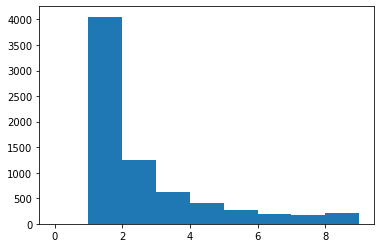

In [10]:
wordfreqs_cat1 = nltk.FreqDist(data['datascience']['all_words'])
plt.hist(wordfreqs_cat1.values(), bins = range(10))
plt.show()

#### Most frequent words within data science posts

In [11]:
print(wordfreqs_cat1.most_common(20))

[('.', 3597), (',', 3570), ('data', 1409), ('?', 1340), (')', 1026), ('(', 962), (':', 740), ('*', 732), ('’', 448), ('science', 445), ('would', 400), ("'m", 390), ('``', 388), ("''", 384), ("'s", 367), ('like', 342), ("n't", 339), ('work', 279), ('time', 269), ('!', 248)]


#### Least Frequent terms within data science posts

In [12]:
print(wordfreqs_cat1.hapaxes())

['27', 'supplies', '//exploreroftruth.medium.com/earn-coursera-certificates-for-free-on-some-programming-courses-during-the-coronavirus-epidemic-e5c468c912b7', 'ii', 'duke', 'learnquest', 'colleagues/', 'co-data', 'premature', 'scrubbed', 'redundancy', 'raising', 'alright', 'refit', '3.1', '2019.', 'motions', 'cross-posted', 'r/askstatistics', 'britain', 'vaccines', 'regional', 'vaccination', 'overdone', 'ptsd', 'time-efficient', 'ineffective', 'weekdays', "'data", 'ds-focused', '4-hour', 'work/on', 'typing', 'myths', 'misconceptions', 'farms', 'grains', 'interchangeably', 'favourite', 'combo', 'low-effort', 'monokai', 'palenight', 'dracula', 'operator', 'mono', 'fira', 'n/a', 'aesthetic', 'relaxed', 'stare', '//bookdown.org/rdpeng/timeseriesbook/spectral-analysis.html', 'periodograms', '40s', 'houston', 'montana', '1099', 'headaches', 'sales-guy', 'workplace', 'up-skill', 'subscription-model', "'pay", 'pace', '//en.m.wikipedia.org/wiki/lyapunov_exponent', '//youtu.be/ic_6jycrbmk', 'we

### Category 2: Game of Thrones

#### Word Frequencies

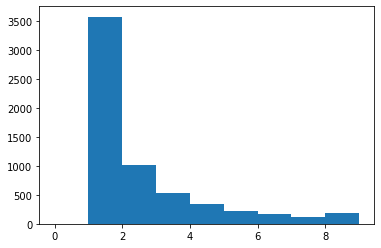

In [13]:
wordfreqs_cat2 = nltk.FreqDist(data['gameofthrones']['all_words'])
plt.hist(wordfreqs_cat2.values(), bins = range(10))
plt.show()

#### Most Frequent words within Game of Thrones posts

In [14]:
print(wordfreqs_cat2.most_common(20))

[('.', 2898), (',', 2478), ('[', 1422), (']', 1420), ('?', 1139), ("'s", 886), ("n't", 494), ('*', 477), (')', 452), ('(', 426), ('s5', 399), (':', 380), ('spoilers', 336), ('show', 327), ('would', 311), ("''", 305), ('``', 277), ('think', 248), ('season', 244), ('like', 243)]


#### Least Frequent words terms within game of thrones posts

In [15]:
print(wordfreqs_cat2.hapaxes())

['/r/got', 'chainmail', '3,500', 'sandsnaked', 'dual', 'daggers-', 'fangs', 'venom.', 's2e2', 'succeeded', 'courtesy', 'vfx', 'crew', 'comrade', 'cleans', 'filth', 'sunset', '/u/atrobro', 'rick', 'morty', 's05e07/books', 'followup', 'boudoir', 'blink', 'accusation', 'vids', 'rampant', '5.4', '11:32pm', '0.8', 'tvbythenumbers', '//tvbythenumbers.zap2it.com/2015/05/27/sunday-cable-ratings-nba-conference-finals-win-night-game-of-thrones-silicon-valley-keeping-up-with-the-kardashians-veep-more/408392/', 'accused', 'pancakes', 'prophesize', 'got-edition', 'board', 'cluedo', 'america', '/r/diy', 'reviving', 'exposed', 'website', 'littlefinger/cersei', 'immense', 'interactive', 'tracking', 'sends', 'arrive', 'possesses', 'preist', 'viserion', 'relased', 'movie', 'originally', 'propositioned', 'trilogy', 'films', 'westboro', 'baptist', 'ha', 'petition', 'rendition', 'astapor', 'partially', 'tyrione', 'plotlines', 'announcing', 'jayne', 'poole', 'sample', 'tullys', 'origin', 'westeros/essos/sot

In [16]:
# manual list takes almost every single character on the keyboard
manual_stopwords = [',','.',')',',','(','m',"'m","n't",'e.g',"'ve",'s','#','/','``',"'s","''",'!','r',']','=','[','s','&','%','*','...','1','2','3','4','5','6','7','8','9','10','--',"''",';','-',':']

## Stemming

In [17]:
stemmer = nltk.SnowballStemmer("english")

In [18]:
def wordStemmer(wordrow): 
    stemmed = [stemmer.stem(word) for word in wordrow]
    return stemmed  

## Process data attempt 2

In [19]:
def data_processing(sql,manual_stopwords):
    c.execute(sql) #1
    data = {'wordMatrix':[],'all_words':[]}
    interWordMatrix = []
    interWordList = []
    row = c.fetchone() #2
    while row is not None:
        tokenizer = nltk.tokenize.RegexpTokenizer(r'\w+') #3 
        wordrow = tokenizer.tokenize(row[0]+" "+row[1])       
        wordrow_lowercased = lowerCaseArray(wordrow)
        wordrow_nostopwords = wordFilter(stopwords,wordrow_lowercased)
        wordrow_nostopwords = wordFilter(manual_stopwords,wordrow_nostopwords)#4
        wordrow_stemmed = wordStemmer(wordrow_nostopwords)
        interWordList.extend(wordrow_stemmed)#5
        interWordMatrix.append(wordrow_stemmed)#6
        row = c.fetchone()#7
        
    wordfreqs = nltk.FreqDist(interWordList)#8
    hapaxes = wordfreqs.hapaxes()#9
    for wordvector in interWordMatrix:
        wordvector_nohapexes = wordFilter(hapaxes,wordvector) #10
        data['wordMatrix'].append(wordvector_nohapexes)
        data['all_words'].extend(wordvector_nohapexes)
        
    return data
#1 create pointer to the sqlite data
#2 fetch the data one by one
#3 row[0] is the title, row[1] is the topic text, we turn them into a single text blob
#4 remove manual stopword
#5 temporary wordlist used to remove hapaxes later on
#6 temporary wordmatrix, will become final wordmatrix after hapaxes removal
#7 get a new topic
#8 make a frequency distribution of all terms
#9 get the list of hapaxes
#10 remove the hapaxes

In [20]:
for subject in subreddits:
    data[subject] = data_processing(sql='''SELECT topicTitle,topicText,topicCategory FROM topics WHERE topicCategory = '''+"'"+subject+"'",manual_stopwords=manual_stopwords)

## Explore data: word frequencies (attempt 2)

### Category 1

### Top 20 most common "Data Science" term after more intense data cleansing  

In [21]:
wordfreqs_cat1 = nltk.FreqDist(data['datascience']['all_words'])
print(wordfreqs_cat1.most_common(20))

[('data', 1971), ('scienc', 955), ('would', 418), ('work', 368), ('use', 347), ('program', 343), ('learn', 342), ('like', 341), ('get', 325), ('scientist', 310), ('job', 268), ('cours', 265), ('look', 257), ('know', 239), ('statist', 228), ('want', 225), ('python', 205), ('year', 204), ('time', 196), ('go', 195)]


### Hapaxes & distribution plot

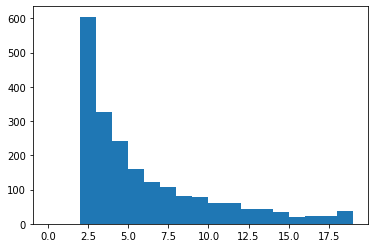

In [22]:
hapaxes_cat1 = wordfreqs_cat1.hapaxes()
plt.hist(wordfreqs_cat1.values(), bins = range(20))
plt.show()

In [23]:
hapaxes_cat1

[]

### Category 2

### Top 20 most common "Game of Thrones" term after more intense data cleansing  

In [24]:
wordfreqs_cat2 = nltk.FreqDist(data['gameofthrones']['all_words'])
print(wordfreqs_cat2.most_common(20))

[('s5', 426), ('spoiler', 373), ('show', 362), ('episod', 300), ('think', 289), ('would', 287), ('season', 286), ('like', 282), ('book', 271), ('one', 249), ('get', 236), ('sansa', 232), ('scene', 216), ('cersei', 213), ('know', 192), ('go', 188), ('king', 183), ('throne', 181), ('see', 177), ('charact', 177)]


### Hapaxes & distribution plot

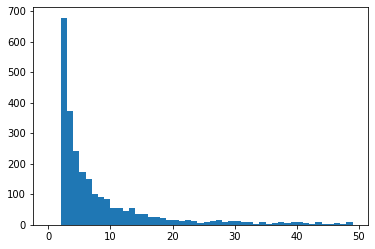

In [25]:
hapaxes_cat2 = wordfreqs_cat2.hapaxes()
plt.hist(wordfreqs_cat2.values(), bins = range(50))
plt.show()

In [26]:
hapaxes_cat2

[]

## Create labeled data

In [27]:
holdoutLength  = 100
#labeled data
labeled_data1 = [(word,'datascience') for word in data['datascience']['wordMatrix'][holdoutLength:]]
labeled_data2 = [(word,'gameofthrones') for word in data['gameofthrones']['wordMatrix'][holdoutLength:]]
labeled_data = []
labeled_data.extend(labeled_data1)
labeled_data.extend(labeled_data2)
#create holdout
holdout_data = data['datascience']['wordMatrix'][:holdoutLength]
holdout_data.extend(data['gameofthrones']['wordMatrix'][:holdoutLength])
holdout_data_labels = ([('datascience') for _ in range(holdoutLength)] + [('gameofthrones') for _ in range(holdoutLength)])

In [28]:
print(len(labeled_data))
print(holdout_data_labels)
print(labeled_data[20])

1647
['datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'datascience', 'dat

In [29]:
data['datascience']['all_words_dedup'] = list(OrderedDict.fromkeys(data['datascience']['all_words']))
data['gameofthrones']['all_words_dedup'] = list(OrderedDict.fromkeys(data['gameofthrones']['all_words']))

In [30]:
all_words = []
all_words.extend(data['datascience']['all_words_dedup'])
all_words.extend(data['gameofthrones']['all_words_dedup'])

In [31]:
all_words_dedup = list(OrderedDict.fromkeys(all_words))

In [32]:
prepared_data = [({word: (word in x[0]) for word in all_words_dedup}, x[1]) for x in labeled_data]
prepared_holdout_data = [({word: (word in x[0]) for word in all_words_dedup}) for x in holdout_data]

In [33]:
print(prepared_data[0])

({'data': False, 'scienc': False, 'freelanc': False, 'current': False, 'master': False, 'program': True, 'studi': False, 'busi': False, 'analyt': False, 'tri': False, 'get': False, 'still': False, 'learn': False, 'skill': False, 'set': False, 'typic': False, 'see': False, 'right': False, 'fair': False, 'profici': False, 'sql': False, 'know': True, 'bit': False, 'find': False, 'job': False, 'analyz': False, 'tv': False, 'campaign': False, 'hi': False, 'kind': False, 'analysi': False, 'done': False, 'around': False, 'run': False, 'brand': False, 'multipl': False, 'spot': False, 'day': False, 'across': False, 'channel': False, 'identifi': False, 'optim': False, 'assum': False, 'respons': False, 'direct': False, 'school': False, 'better': False, 'got': False, 'accept': False, 'two': False, 'one': False, 'lewi': False, 'univers': False, 'provid': False, 'fulli': False, 'onlin': False, 'credit': False, 'depaul': False, 'predict': False, 'requir': False, 'bachelor': False, 'physic': False, 'a

random.shuffle(prepared_data)
train_size = int(len(prepared_data) * 0.75)
train = prepared_data[:train_size]
test = prepared_data[train_size:]

# Text Analytics

## Naive Bayes

In [42]:
nbr_got = 0
nbr_data = 0
for set in train:
    if set[1]=='datascience':
        nbr_data+=1
    if set[1]=='gameofthrones':
        nbr_got+=1
print(nbr_got)
print(nbr_data)

590
645


In [43]:
classifier  = nltk.NaiveBayesClassifier.train(train)

In [44]:
nltk.classify.accuracy(classifier, test)

0.9902912621359223

In [45]:
print(classifier.show_most_informative_features(20))

Most Informative Features
                      tv = True           gameof : datasc =     62.3 : 1.0
                  season = True           gameof : datasc =     53.6 : 1.0
                   scene = True           gameof : datasc =     51.4 : 1.0
                 analysi = True           datasc : gameof =     46.7 : 1.0
                    king = True           gameof : datasc =     42.6 : 1.0
                   appli = True           datasc : gameof =     36.9 : 1.0
                research = True           datasc : gameof =     28.4 : 1.0
                    kill = True           gameof : datasc =     26.0 : 1.0
                  episod = True           gameof : datasc =     23.0 : 1.0
                 student = True           datasc : gameof =     22.3 : 1.0
                      hi = True           datasc : gameof =     21.0 : 1.0
                 process = True           datasc : gameof =     20.4 : 1.0
                     man = True           gameof : datasc =     17.7 : 1.0

In [46]:
classified_data = classifier.classify_many(prepared_holdout_data)

In [47]:
cm = nltk.ConfusionMatrix(holdout_data_labels, classified_data)
print(cm)

              |     g |
              |     a |
              |  d  m |
              |  a  e |
              |  t  o |
              |  a  f |
              |  s  t |
              |  c  h |
              |  i  r |
              |  e  o |
              |  n  n |
              |  c  e |
              |  e  s |
--------------+-------+
  datascience |<78>22 |
gameofthrones |  2<98>|
--------------+-------+
(row = reference; col = test)



## Decision trees

In [49]:
classifier2 = nltk.DecisionTreeClassifier.train(train)

In [50]:
nltk.classify.accuracy(classifier2, test)

0.9393203883495146

In [51]:
print(classifier2.pseudocode(depth=4))

if data == False: 
  if python == False: 
    if learn == False: 
      if tool == False: return 'gameofthrones'
      if tool == True: return 'datascience'
    if learn == True: 
      if know == False: return 'datascience'
      if know == True: return 'datascience'
  if python == True: return 'datascience'
if data == True: return 'datascience'



In [52]:
classified_data2 = classifier2.classify_many(prepared_holdout_data)

In [53]:
cm = nltk.ConfusionMatrix(holdout_data_labels, classified_data2)
print(cm)

              |       g |
              |       a |
              |   d   m |
              |   a   e |
              |   t   o |
              |   a   f |
              |   s   t |
              |   c   h |
              |   i   r |
              |   e   o |
              |   n   n |
              |   c   e |
              |   e   s |
--------------+---------+
  datascience | <18> 82 |
gameofthrones |   .<100>|
--------------+---------+
(row = reference; col = test)

